# Day 064 — Unsupervised Clustering Evaluation Lab

> **Goal**: Clustering algorithms operate without ground-truth targets. How do we evaluate their quality quantitatively? Today, we will explore both **External metrics** (used when ground truth labels are available) and **Internal metrics** (used when ground truth is unknown) alongside mathematical formulations.


In [1]:
# ============================================================
# Setup & Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('All imports ready!')


All imports ready!


---
## 1. Dataset Generation & Algorithm Execution


Dataset: 500 samples, 5 features
True Clusters: 4


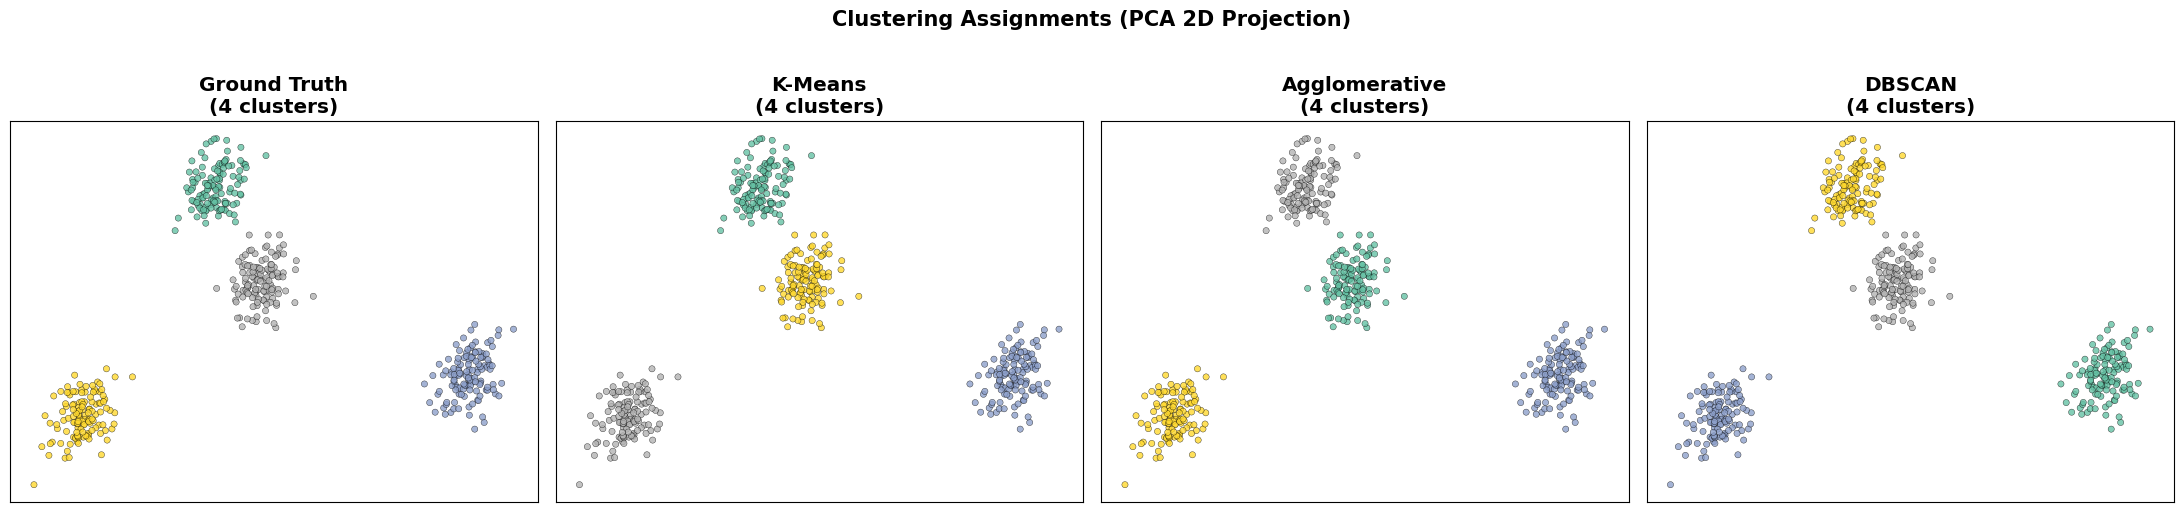

In [2]:
# ── Generate synthetic cluster data ──
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8,
                       random_state=42, n_features=5)
X_scaled = StandardScaler().fit_transform(X)

print(f'Dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features')
print(f'True Clusters: {len(np.unique(y_true))}')

km_labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)
agg_labels = AgglomerativeClustering(n_clusters=4).fit_predict(X_scaled)
db_labels = DBSCAN(eps=0.8, min_samples=5).fit_predict(X_scaled)

from sklearn.decomposition import PCA
X_2d = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
all_labels = [y_true, km_labels, agg_labels, db_labels]
titles = ['Ground Truth', 'K-Means', 'Agglomerative', 'DBSCAN']

for ax, labels, title in zip(axes, all_labels, titles):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='Set2',
               s=20, alpha=0.8, edgecolors='black', linewidth=0.3)
    n_clusters = len(set(labels) - {-1})
    ax.set_title(f'{title}\n({n_clusters} clusters)', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Clustering Assignments (PCA 2D Projection)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 2. External Metric: Adjusted Rand Index (ARI)

### 📖 Theory

The Adjusted Rand Index evaluates the agreement between cluster assignments $K$ and ground truth class assignments $C$, adjusted for chance.

#### Rand Index (Unadjusted)

$$RI = \frac{a + b}{\binom{n}{2}}$$

where $a$ is the number of point pairs in the same cluster and class, and $b$ is the number of point pairs in different clusters and classes.

#### Adjusted Rand Index (ARI)

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

| ARI Score | Interpretation |
|-----------|----------------|
| **1.0** | Perfect cluster assignment match. |
| **0.0** | Random assignment baseline. |
| **$<0$** | Systematic misclassification (worse than random). |


In [3]:
# ── Calculate ARI Scores ──
from sklearn.metrics import adjusted_rand_score

ari_km = adjusted_rand_score(y_true, km_labels)
ari_agg = adjusted_rand_score(y_true, agg_labels)
ari_db = adjusted_rand_score(y_true, db_labels)

print('Adjusted Rand Index (ARI) Benchmarks:')
print(f'  K-Means       : {ari_km:.4f}')
print(f'  Agglomerative : {ari_agg:.4f}')
print(f'  DBSCAN        : {ari_db:.4f}')


Adjusted Rand Index (ARI) Benchmarks:
  K-Means       : 1.0000
  Agglomerative : 1.0000
  DBSCAN        : 1.0000


---
## 3. External Metric: Normalized Mutual Information (NMI)

### 📖 Theory

NMI measures the shared information between ground truth $U$ and predicted clustering $V$, scaled between 0 and 1:

$$NMI(U, V) = \frac{2 \cdot MI(U, V)}{H(U) + H(V)}$$

where $MI(U, V)$ is the mutual information and $H(U)$ represents Shannon entropy.


In [4]:
# ── Calculate NMI Scores ──
from sklearn.metrics import normalized_mutual_info_score

nmi_km = normalized_mutual_info_score(y_true, km_labels)
nmi_agg = normalized_mutual_info_score(y_true, agg_labels)
nmi_db = normalized_mutual_info_score(y_true, db_labels)

print('Normalized Mutual Information (NMI) Benchmarks:')
print(f'  K-Means       : {nmi_km:.4f}')
print(f'  Agglomerative : {nmi_agg:.4f}')
print(f'  DBSCAN        : {nmi_db:.4f}')


Normalized Mutual Information (NMI) Benchmarks:
  K-Means       : 1.0000
  Agglomerative : 1.0000
  DBSCAN        : 1.0000


---
## 4. Internal Metric: Silhouette Analysis

### 📖 Theory

Silhouette analysis measures cluster cohesion versus separation **without requiring target labels**.

For sample point $i$:
- $a(i)$: Mean intra-cluster distance to all other points in the same cluster.
- $b(i)$: Mean distance to points in the nearest neighboring cluster.

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

Overall Silhouette Score $S = \frac{1}{n} \sum_{i=1}^n s(i)$.


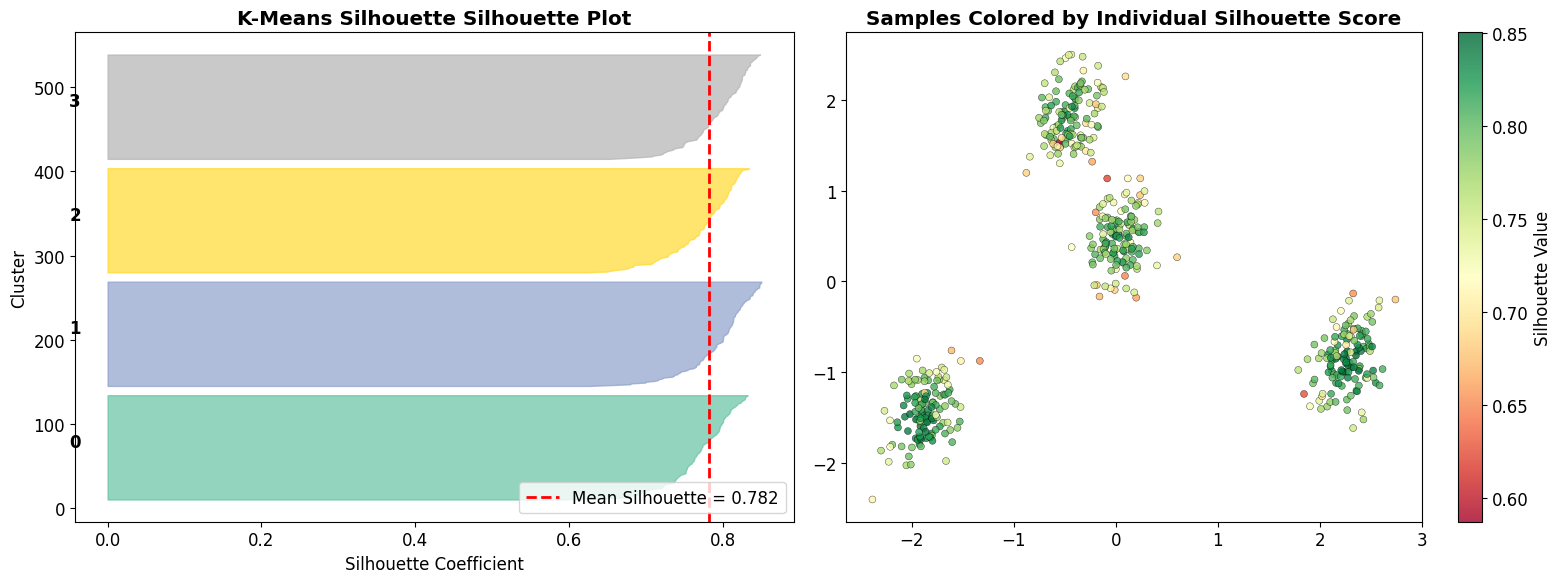

In [5]:
# ── Silhouette Evaluation & Visuals ──
from sklearn.metrics import silhouette_score, silhouette_samples

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sample_silhouette_values = silhouette_samples(X_scaled, km_labels)
overall_silhouette = silhouette_score(X_scaled, km_labels)

y_lower = 10
n_clusters = len(np.unique(km_labels))
colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cluster_sil_values = sample_silhouette_values[km_labels == i]
    cluster_sil_values.sort()
    y_upper = y_lower + len(cluster_sil_values)
    
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_values,
                          facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    axes[0].text(-0.05, y_lower + 0.5 * len(cluster_sil_values), str(i), fontweight='bold')
    y_lower = y_upper + 10

axes[0].axvline(x=overall_silhouette, color='red', linestyle='--', linewidth=2,
                label=f'Mean Silhouette = {overall_silhouette:.3f}')
axes[0].set_xlabel('Silhouette Coefficient')
axes[0].set_ylabel('Cluster')
axes[0].set_title('K-Means Silhouette Silhouette Plot', fontweight='bold')
axes[0].legend(loc='lower right')

scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=sample_silhouette_values,
                          cmap='RdYlGn', s=25, alpha=0.8, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, ax=axes[1], label='Silhouette Value')
axes[1].set_title('Samples Colored by Individual Silhouette Score', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 5. Davies-Bouldin Index & Calinski-Harabasz Score

### 📖 Davies-Bouldin Index (DBI)

Evaluates the ratio of intra-cluster dispersion to inter-cluster distance. **Lower values indicate superior clustering.**

$$DBI = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(c_i, c_j)} \right)$$

### 📖 Calinski-Harabasz Score (Variance Ratio Criterion)

Ratio of between-cluster variance to within-cluster variance. **Higher values indicate better-defined clusters.**

$$CH = \frac{\text{tr}(B_k) / (k-1)}{\text{tr}(W_k) / (n-k)}$$


In [6]:
# ── Internal Validation Comparison ──
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

metrics = []
for name, labels in [('K-Means', km_labels), ('Agglomerative', agg_labels)]:
    metrics.append({
        'Algorithm': name,
        'Silhouette (Higher Best)': silhouette_score(X_scaled, labels),
        'Davies-Bouldin (Lower Best)': davies_bouldin_score(X_scaled, labels),
        'Calinski-Harabasz (Higher Best)': calinski_harabasz_score(X_scaled, labels)
    })

df_metrics = pd.DataFrame(metrics)
print('Internal Validation Table:')
print(df_metrics.round(4).to_string(index=False))


Internal Validation Table:
    Algorithm  Silhouette (Higher Best)  Davies-Bouldin (Lower Best)  Calinski-Harabasz (Higher Best)
      K-Means                     0.782                       0.3089                        2925.1947
Agglomerative                     0.782                       0.3089                        2925.1947


---
## 6. Determining Optimal Cluster Count ($k$)


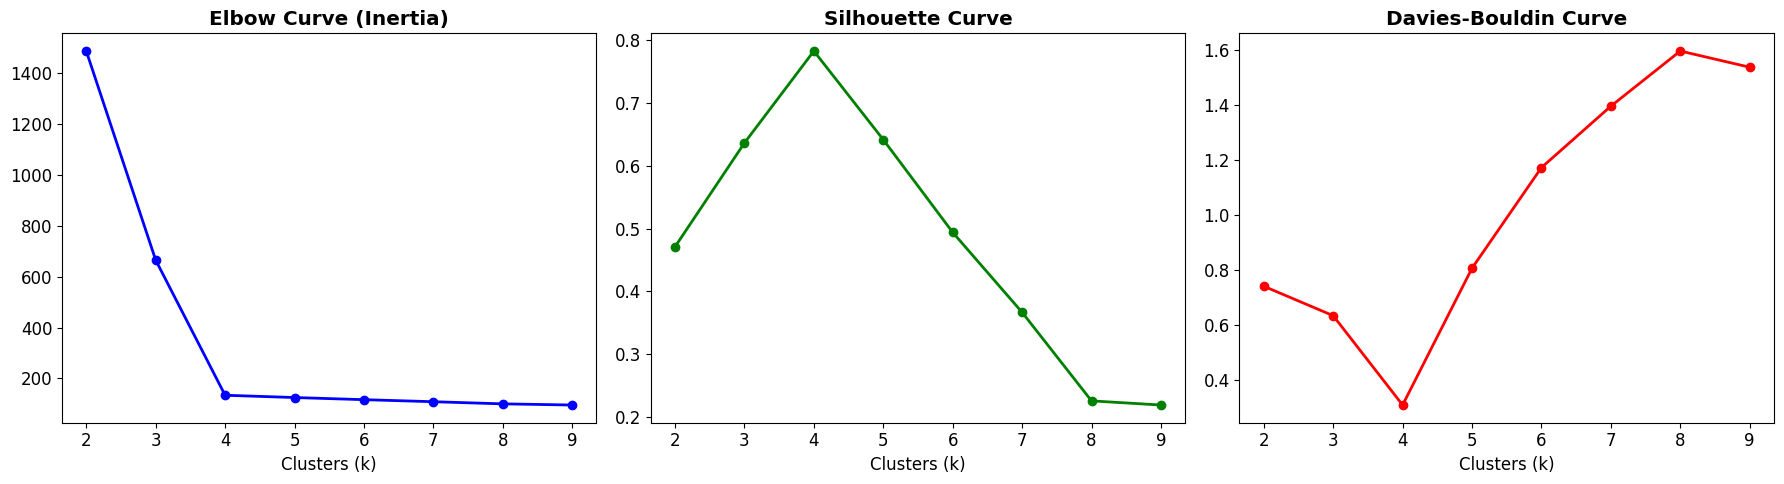

In [7]:
# ── Elbow + Silhouette Optimization Sweep ──
k_range = range(2, 10)
inertias, silhouettes, dbi_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Curve (Inertia)', fontweight='bold')
axes[0].set_xlabel('Clusters (k)')

axes[1].plot(k_range, silhouettes, 'go-', linewidth=2)
axes[1].set_title('Silhouette Curve', fontweight='bold')
axes[1].set_xlabel('Clusters (k)')

axes[2].plot(k_range, dbi_scores, 'ro-', linewidth=2)
axes[2].set_title('Davies-Bouldin Curve', fontweight='bold')
axes[2].set_xlabel('Clusters (k)')

plt.tight_layout()
plt.show()


---
## 7. Cluster Profiling & Feature Characterization


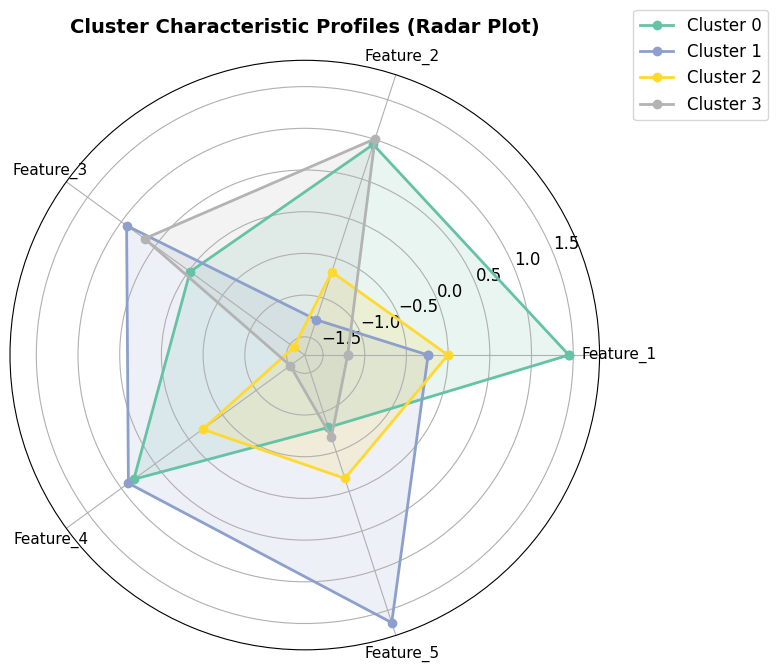

In [8]:
# ── Feature Radar Chart ──
feature_names = [f'Feature_{i+1}' for i in range(X_scaled.shape[1])]
df_profile = pd.DataFrame(X_scaled, columns=feature_names)
df_profile['Cluster'] = km_labels

cluster_means = df_profile.groupby('Cluster')[feature_names].mean()
angles = np.linspace(0, 2*np.pi, len(feature_names), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_means)))

for i, (cluster_id, row) in enumerate(cluster_means.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_names, fontsize=11)
ax.set_title('Cluster Characteristic Profiles (Radar Plot)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


---
## 8. Comprehensive Clustering Evaluation Benchmark Matrix


In [9]:
# ── Complete Evaluation Benchmark ──
from sklearn.metrics import v_measure_score, homogeneity_score, completeness_score

benchmark = []
for name, labels in [('K-Means', km_labels), ('Agglomerative', agg_labels)]:
    benchmark.append({
        'Algorithm': name,
        'ARI': adjusted_rand_score(y_true, labels),
        'NMI': normalized_mutual_info_score(y_true, labels),
        'V-Measure': v_measure_score(y_true, labels),
        'Silhouette': silhouette_score(X_scaled, labels),
        'DBI': davies_bouldin_score(X_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels)
    })

df_bench = pd.DataFrame(benchmark)
print('Comprehensive Evaluation Summary:')
print(df_bench.round(4).to_string(index=False))


Comprehensive Evaluation Summary:
    Algorithm  ARI  NMI  V-Measure  Silhouette    DBI  Calinski-Harabasz
      K-Means  1.0  1.0        1.0       0.782 0.3089          2925.1947
Agglomerative  1.0  1.0        1.0       0.782 0.3089          2925.1947


---
## 📝 Key Takeaways

1. **External Metrics (ARI, NMI)**: Compare partitions against true ground-truth labels.
2. **Silhouette Score**: Evaluates cluster separation; values close to 1 indicate dense, isolated clusters.
3. **Davies-Bouldin Index**: Lower values denote tight clusters with high inter-cluster distance.
4. **Calinski-Harabasz Index**: Higher scores indicate distinct, well-separated cluster variance ratios.
